# Quantitative Results Analysis

Load a dataset's per-sample result CSV and plot one metric against another. Change `x_metric` / `y_metric` (and the `model` / `dataset`) to study different aspects of the results.

In [10]:
from __future__ import annotations

import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

ROOT = Path.cwd()
if not (ROOT / "results").exists():
    ROOT = Path.cwd().parents[0]
RESULTS_DIR = ROOT / "results"
EDA_DIR = ROOT / "analysis" / "eda"

## Helpers

In [11]:
def result_dir(model: str, dataset: str, protocol: str = "gt_bbox") -> Path:
    return RESULTS_DIR / f"{model}_{protocol}_{dataset}"


def load_results(model: str, dataset: str, protocol: str = "gt_bbox") -> tuple[pd.DataFrame, dict]:
    folder = result_dir(model, dataset, protocol)
    metrics_path = folder / "per_sample_metrics.csv"
    summary_path = folder / "summary.json"
    if not metrics_path.exists():
        raise FileNotFoundError(metrics_path)
    df = pd.read_csv(metrics_path)
    summary = json.loads(summary_path.read_text()) if summary_path.exists() else {}
    return add_derived_metrics(df, dataset), summary


def add_derived_metrics(df: pd.DataFrame, dataset: str) -> pd.DataFrame:
    """Add columns that aren't stored in the CSV but are handy to plot against."""
    df = df.copy()
    df["relative_target_area"] = df.apply(_bbox_relative_area, axis=1)
    stats_path = EDA_DIR / dataset / "sample_stats.csv"
    if stats_path.exists():
        stats_cols = [
            "sample_id",
            "target_area_pixels",
            "target_area_fraction",
            "bbox_area_pixels",
            "bbox_area_fraction",
            "target_bbox_area_ratio",
            "component_count",
            "largest_component_area_pixels",
        ]
        stats = pd.read_csv(stats_path, usecols=lambda col: col in stats_cols)
        df = df.merge(stats, on="sample_id", how="left")
    return df


def _bbox_relative_area(row: pd.Series) -> float:
    """Target size as bbox area / image area (proxy for relative target area)."""
    boxes = np.asarray(json.loads(row["bbox"]), dtype=float).reshape(-1, 4)
    box_area = float(np.sum((boxes[:, 2] - boxes[:, 0]) * (boxes[:, 3] - boxes[:, 1])))
    image_area = float(row["height"]) * float(row["width"])
    return box_area / image_area if image_area else np.nan


def scatter_metrics(
    df: pd.DataFrame,
    x_metric: str,
    y_metric: str,
    *,
    title: str = "",
    logx: bool = False,
) -> None:
    fig, ax = plt.subplots(figsize=(6.5, 5))
    ax.scatter(df[x_metric], df[y_metric], s=18, alpha=0.5, edgecolor="none")
    ax.set_xlabel(x_metric)
    ax.set_ylabel(y_metric)
    if logx:
        ax.set_xscale("log")
    if title:
        ax.set_title(title)
    r = df[[x_metric, y_metric]].corr().iloc[0, 1]
    ax.text(0.02, 0.98, f"r = {r:.2f}  (n={len(df)})", transform=ax.transAxes, va="top", fontsize=9)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

## Load Results

In [12]:
model = "ultrasam"
dataset = "busi"
protocol = "gt_bbox"

df, summary = load_results(model, dataset, protocol)
df[[
    "sample_id",
    "dice",
    "hd95",
    "iou",
    "target_area_fraction",
    "bbox_area_fraction",
    "target_bbox_area_ratio",
    "component_count",
    "relative_target_area",
]].describe()

,dice,hd95,iou,target_area_fraction,bbox_area_fraction,target_bbox_area_ratio,component_count,relative_target_area
count,647.000000,647.000000,647.000000,647.000000,647.000000,647.000000,647.000000,647.000000
mean,0.924275,14.833667,0.861727,0.094354,0.136904,0.718702,1.109737,0.134261
std,0.040892,13.950316,0.066438,0.098776,0.143099,0.099602,0.399707,0.141866
min,0.651935,2.236068,0.483608,0.002812,0.003262,0.211688,1.000000,0.003090
25%,0.909954,5.000000,0.834784,0.022401,0.030317,0.661401,1.000000,0.029067
50%,0.935021,9.219544,0.877971,0.057643,0.088748,0.743146,1.000000,0.085342
75%,0.951715,19.979336,0.907879,0.130898,0.182499,0.789591,1.000000,0.179688
max,0.982368,109.414578,0.965347,0.562924,0.726797,0.905405,5.000000,0.723459


## Plot One Metric Against Another

Change `x_metric` / `y_metric` to study different aspects.

Result metrics include: `dice`, `iou`, `precision`, `recall`, `hd95`, `assd`, `relative_area_error`, `infer_ms`.

EDA measurements joined from `analysis/eda/<dataset>/sample_stats.csv` include: `target_area_pixels`, `target_area_fraction`, `bbox_area_pixels`, `bbox_area_fraction`, `target_bbox_area_ratio`, `component_count`, `largest_component_area_pixels`.

Notebook-derived prompt-size proxy: `relative_target_area` = bbox area / image area.

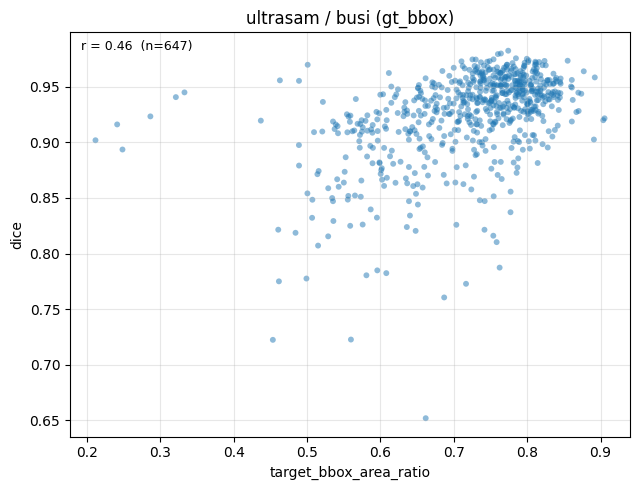

In [13]:
x_metric = "target_bbox_area_ratio"
y_metric = "dice"

scatter_metrics(df, x_metric, y_metric, title=f"{model} / {dataset} ({protocol})", logx=False)

## All Datasets On One Plot

Overlay every dataset for the chosen `model` / `protocol`, colored by dataset.

In [14]:
def find_datasets(model: str, protocol: str = "gt_bbox") -> list[str]:
    prefix = f"{model}_{protocol}_"
    return sorted(p.name[len(prefix):] for p in RESULTS_DIR.glob(f"{prefix}*") if p.is_dir())


def _scatter_on_ax(ax, model, datasets, x_metric, y_metric, protocol, logx):
    cmap = plt.get_cmap("tab20")
    for i, dataset in enumerate(datasets):
        try:
            d, _ = load_results(model, dataset, protocol)
        except FileNotFoundError:
            continue
        ax.scatter(d[x_metric], d[y_metric], s=14, alpha=0.5, edgecolor="none",
                   color=cmap(i % 20), label=f"{dataset} (n={len(d)})")
    ax.set_xlabel(x_metric + (" (log)" if logx else ""))
    ax.set_ylabel(y_metric)
    if logx:
        ax.set_xscale("log")
    ax.grid(True, alpha=0.3)


def scatter_metrics_by_dataset(
    model: str,
    datasets: list[str],
    x_metric: str,
    y_metric: str,
    *,
    protocol: str = "gt_bbox",
    logx: bool = False,
) -> None:
    fig, ax = plt.subplots(figsize=(8, 6))
    _scatter_on_ax(ax, model, datasets, x_metric, y_metric, protocol, logx)
    ax.set_title(f"{model} ({protocol})")
    ax.legend(fontsize=8, markerscale=1.5, loc="best")
    plt.tight_layout()
    plt.show()


def scatter_metrics_lin_and_log(
    model: str,
    datasets: list[str],
    x_metric: str,
    y_metric: str,
    *,
    protocol: str = "gt_bbox",
) -> None:
    fig, axes = plt.subplots(1, 2, figsize=(15, 6), sharey=True)
    _scatter_on_ax(axes[0], model, datasets, x_metric, y_metric, protocol, logx=False)
    _scatter_on_ax(axes[1], model, datasets, x_metric, y_metric, protocol, logx=True)
    axes[0].set_title("linear x")
    axes[1].set_title("log x")
    axes[1].legend(fontsize=8, markerscale=1.5, loc="best")
    fig.suptitle(f"{model} ({protocol})")
    plt.tight_layout()
    plt.show()

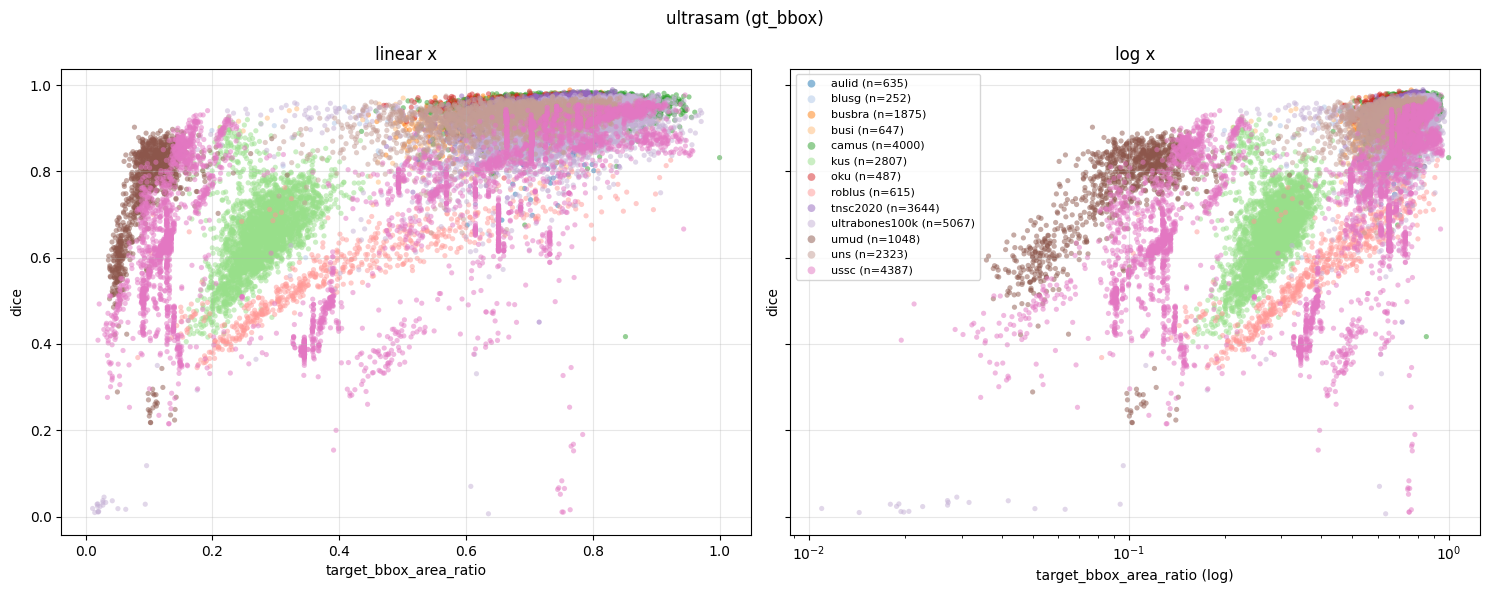

In [15]:
datasets = find_datasets(model, protocol)
# datasets = [d for d in datasets if d != "kus_savevis10"]  # drop subsets/dupes if needed
scatter_metrics_lin_and_log(model, datasets, x_metric, y_metric, protocol=protocol)

## Individual Datasets (Small Multiples)

One subplot per dataset, so trends within each dataset are easy to read.

In [18]:
def scatter_metrics_per_dataset(
    model: str,
    datasets: list[str],
    x_metric: str,
    y_metric: str,
    *,
    protocol: str = "gt_bbox",
    logx: bool = False,
    ncols: int = 5,
) -> None:
    datasets = list(datasets)
    nrows = -(-len(datasets) // ncols)  # ceil
    fig, axes = plt.subplots(nrows, ncols, figsize=(4 * ncols, 3.2 * nrows),
                             sharey=True, squeeze=False)
    cmap = plt.get_cmap("tab20")
    for ax, (i, dataset) in zip(axes.ravel(), enumerate(datasets)):
        try:
            d, _ = load_results(model, dataset, protocol)
        except FileNotFoundError:
            ax.set_visible(False)
            continue
        ax.scatter(d[x_metric], d[y_metric], s=14, alpha=0.5, edgecolor="none", color=cmap(i % 20))
        r = d[[x_metric, y_metric]].corr().iloc[0, 1]
        ax.set_title(f"{dataset} (n={len(d)}, r={r:.2f})", fontsize=9)
        ax.set_xlabel(x_metric + (" (log)" if logx else ""), fontsize=8)
        if logx:
            ax.set_xscale("log")
        ax.grid(True, alpha=0.3)
    for ax in axes.ravel()[len(datasets):]:
        ax.set_visible(False)
    for ax in axes[:, 0]:
        ax.set_ylabel(y_metric, fontsize=8)
    fig.suptitle(f"{model} ({protocol}) — {y_metric} vs {x_metric}" + (" (log x)" if logx else ""))
    plt.tight_layout()
    plt.show()


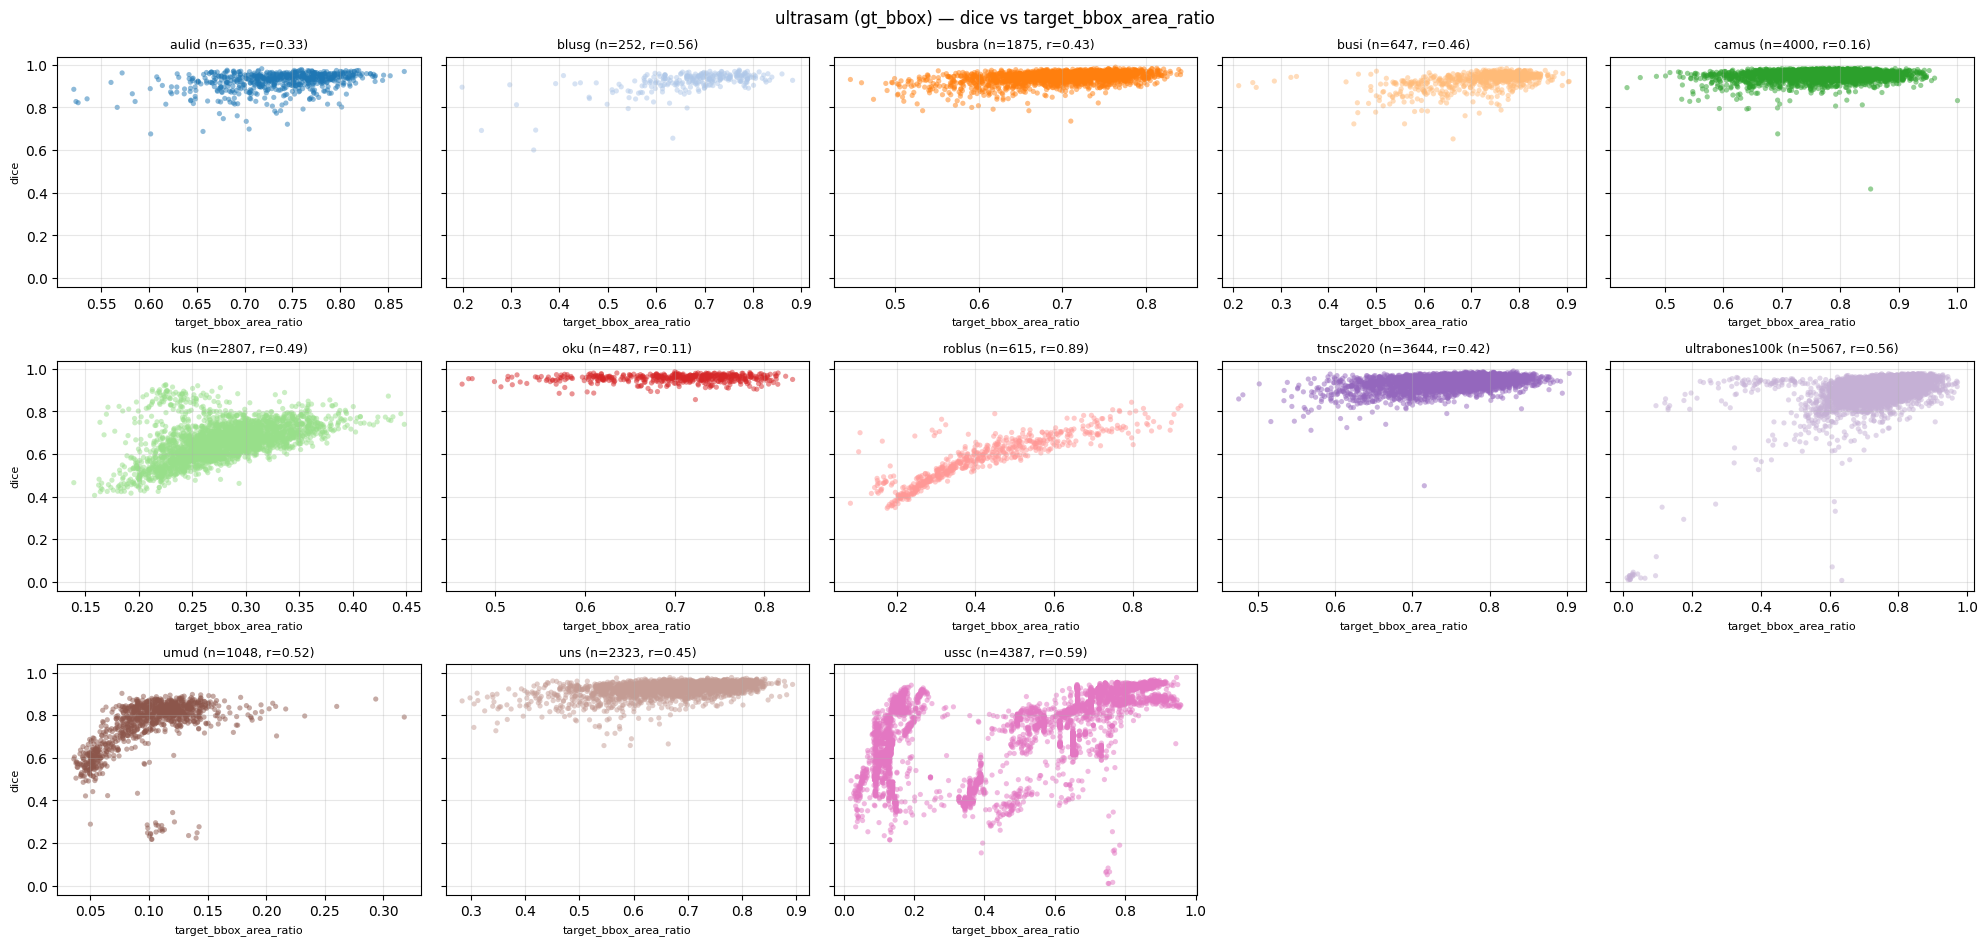

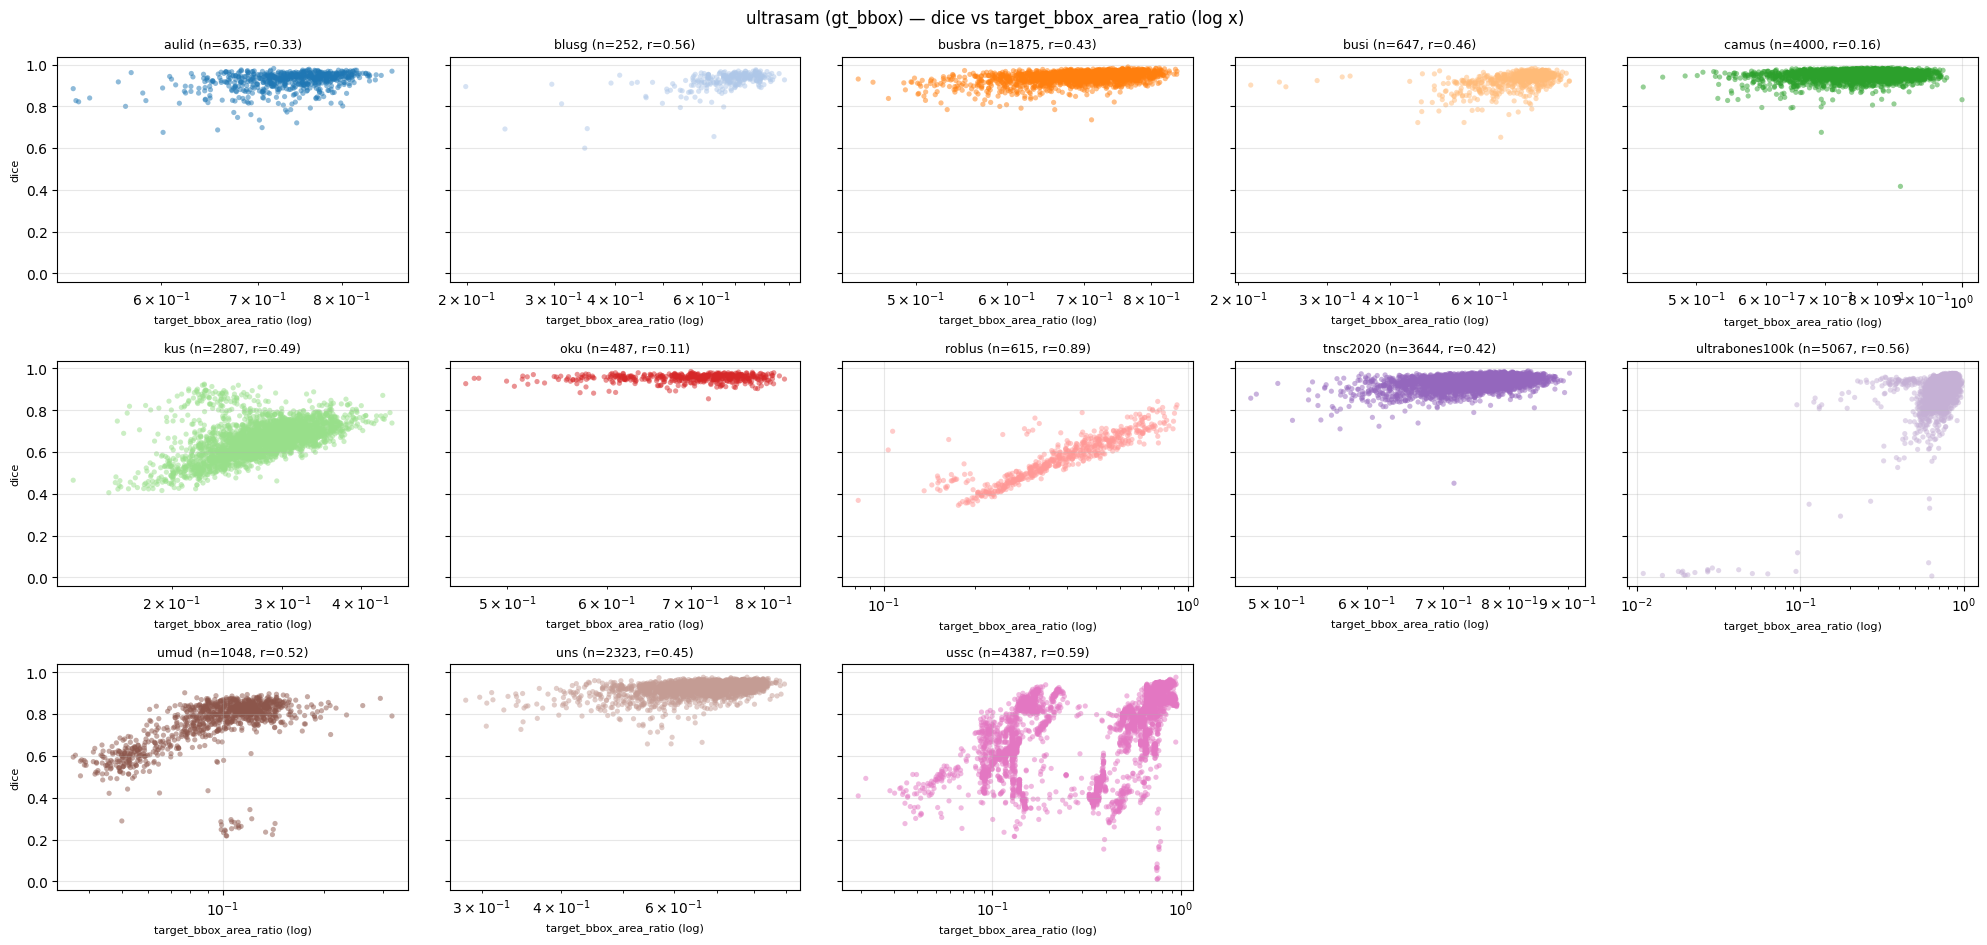

In [19]:
scatter_metrics_per_dataset(model, datasets, x_metric, y_metric, protocol=protocol, logx=False, ncols=5)
scatter_metrics_per_dataset(model, datasets, x_metric, y_metric, protocol=protocol, logx=True, ncols=5)